# HW10-11 – Компьютерное зрение в PyTorch: CNN, Transfer Learning, Detection

**Часть A (S10):** классификация изображений на STL10 — CNN с нуля, аугментации, transfer learning на ResNet18.  
**Часть B (S11):** детекция объектов — готовая pretrained модель FasterRCNN, два режима score_threshold, IoU/precision/recall.

Структура ноутбука:
1. Импорты, seed, устройство
2. Данные и DataLoader (Часть A — STL10, Часть B — Pascal VOC)
3. Базовые функции обучения и оценки
4. Эксперименты C1–C4 (классификация)
5. Выбор лучшей модели и финальный test
6. Артефакты части A (графики, модель, config)
7. Часть B: Detection (V1, V2)
8. Сохранение runs.csv

## 1. Импорты, seed, устройство

In [5]:
import os
import json
import math
import time
import random
import csv
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [6]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Режим быстрого запуска для отладки (True = меньше данных и эпох)
FAST_MODE = False
DATA_DIR = "./data"
ARTIFACTS_DIR = "./artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 5 if FAST_MODE else 15

Device: cuda


## 2. Данные и DataLoader

### 2.1 Часть A: STL10

STL10: 10 классов, изображения 96×96 RGB. Официальный split: train (5000 изображений) и test (8000 изображений). Из train отделяем 20% для val.

Готовим три варианта transforms:
- `base_tf` — базовый без аугментаций (для C1)
- `aug_tf` — с аугментациями (для C2)
- `resnet_train_tf` / `resnet_eval_tf` — для ResNet18 с pretrained ImageNet weights (для C3, C4)

In [7]:
# STL10 mean/std (стандартные значения)
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD  = (0.2603, 0.2566, 0.2713)

# ImageNet mean/std для ResNet
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

IMG_SIZE_CNN = 96    # STL10 native
IMG_SIZE_RN  = 224   # ResNet standard

# C1: базовый transform (без аугментаций)
base_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

# C2: transform с аугментациями
aug_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(96, padding=12),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

# C3/C4: ResNet transforms (train + eval)
resnet_train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE_RN + 32),
    transforms.RandomResizedCrop(IMG_SIZE_RN, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

resnet_eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE_RN + 32),
    transforms.CenterCrop(IMG_SIZE_RN),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transforms сконфигурированы.")

Transforms сконфигурированы.


In [8]:
def load_stl10(transform, split: str = "train"):
    return torchvision.datasets.STL10(
        root=DATA_DIR, split=split, download=True, transform=transform
    )

def make_cnn_loaders(
    transform_train,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    """Создаём train/val/test загрузчики для SimpleCNN экспериментов."""
    ds_train_full = load_stl10(transform_train, split="train")
    ds_test_base  = load_stl10(base_tf, split="test")  # test всегда без аугментаций

    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val_aug = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    # Для val нужны базовые transforms (без аугментаций)
    ds_train_eval = load_stl10(base_tf, split="train")
    val_indices = ds_val_aug.indices
    ds_val = Subset(ds_train_eval, val_indices)

    if fast_mode:
        rng = np.random.RandomState(seed)
        ti = rng.choice(len(ds_train), size=min(2000, len(ds_train)), replace=False)
        vi = rng.choice(len(ds_val), size=min(500, len(ds_val)), replace=False)
        ti2 = rng.choice(len(ds_test_base), size=min(500, len(ds_test_base)), replace=False)
        ds_train = Subset(ds_train, ti)
        ds_val   = Subset(ds_val, vi)
        ds_test_base = Subset(ds_test_base, ti2)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_base, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader


def make_resnet_loaders(
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    """Создаём train/val/test загрузчики для ResNet экспериментов."""
    ds_train_aug  = load_stl10(resnet_train_tf, split="train")
    ds_train_eval = load_stl10(resnet_eval_tf,  split="train")
    ds_test       = load_stl10(resnet_eval_tf,  split="test")

    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)
    val_idx   = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        rng2 = np.random.RandomState(seed + 1)
        ti = rng2.choice(len(ds_train), size=min(2000, len(ds_train)), replace=False)
        vi = rng2.choice(len(ds_val), size=min(500, len(ds_val)), replace=False)
        ti2 = rng2.choice(len(ds_test), size=min(500, len(ds_test)), replace=False)
        ds_train = Subset(ds_train, ti)
        ds_val   = Subset(ds_val, vi)
        ds_test  = Subset(ds_test, ti2)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader


# Создаём loaders для C1/C2 (базовый, без аугментаций для начала)
train_loader_base, val_loader_base, test_loader_base = make_cnn_loaders(base_tf)
train_loader_aug,  val_loader_aug,  test_loader_aug  = make_cnn_loaders(aug_tf)
train_loader_rn,   val_loader_rn,   test_loader_rn   = make_resnet_loaders()

# Получаем класс-имена
ds_tmp = load_stl10(base_tf, split="train")
class_names = ds_tmp.classes
NUM_CLASSES = len(class_names)
print(f"Классы ({NUM_CLASSES}):", class_names)

# Sanity-check: форма батча
x, y = next(iter(train_loader_base))
print("x.shape:", x.shape, "dtype:", x.dtype)
print("y.shape:", y.shape, "dtype:", y.dtype)
print("Batch size:", x.size(0))

100%|██████████| 2.64G/2.64G [03:31<00:00, 12.5MB/s]


Классы (10): ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
x.shape: torch.Size([64, 3, 96, 96]) dtype: torch.float32
y.shape: torch.Size([64]) dtype: torch.int64
Batch size: 64


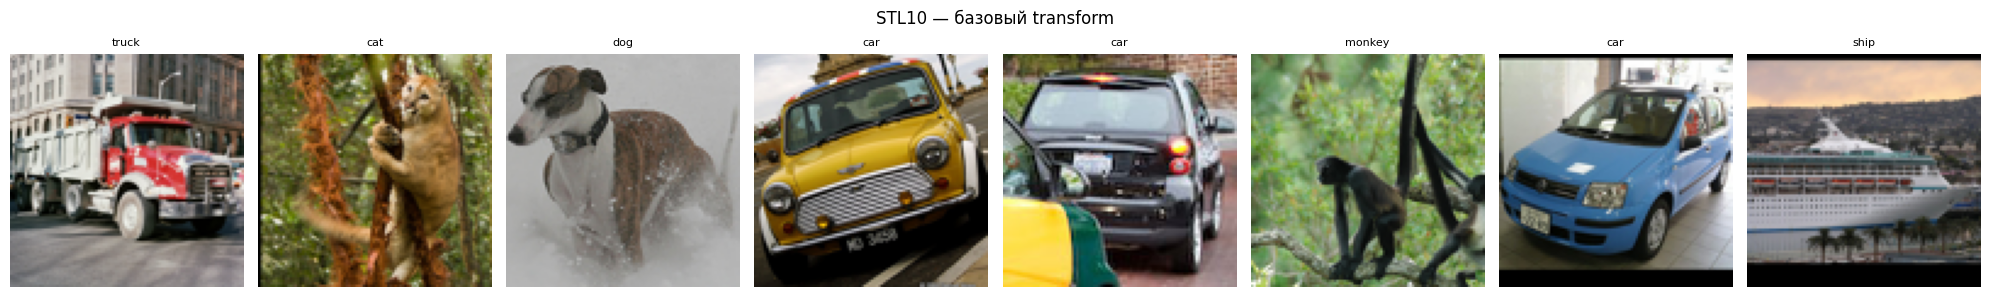

In [9]:
# Sanity-check: визуализация нескольких примеров из STL10

def denorm_stl10(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std  = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_samples(loader, n: int = 8, title: str = "") -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(2.5 * n, 3))
    plt.suptitle(title, fontsize=12)
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl10(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_loader_base, n=8, title="STL10 — базовый transform")

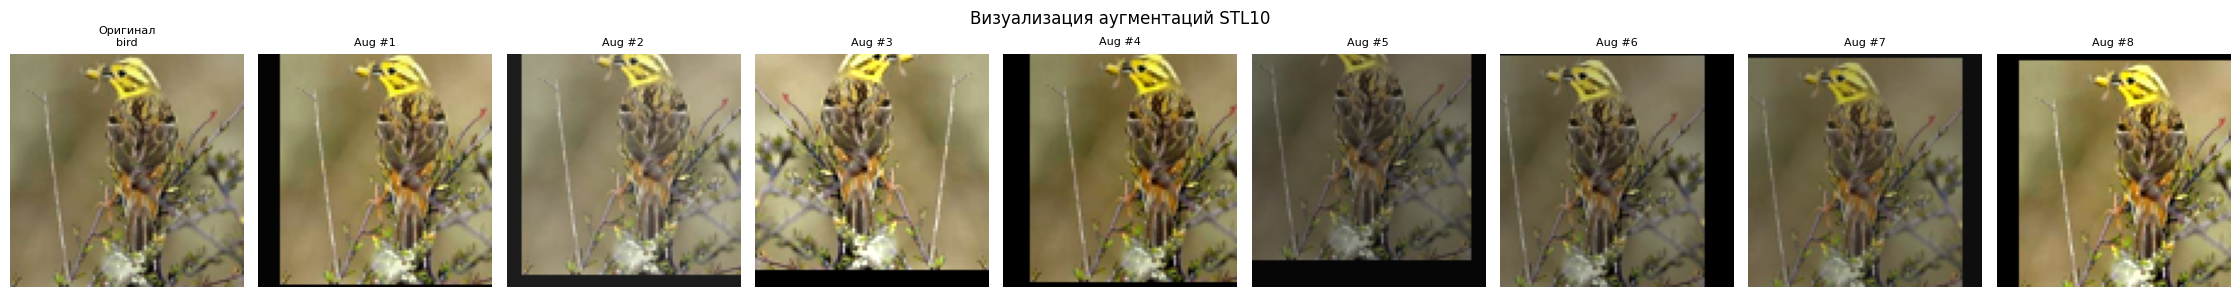

Сохранено: augmentations_preview.png


In [10]:
# Визуализация аугментаций: одно и то же изображение с разными transforms

ds_raw = torchvision.datasets.STL10(root=DATA_DIR, split="train", download=True, transform=None)
img_pil, label = ds_raw[0]

n_aug_samples = 8
fig, axes = plt.subplots(1, n_aug_samples + 1, figsize=(2.5 * (n_aug_samples + 1), 3))

# Оригинал
axes[0].imshow(img_pil)
axes[0].set_title(f"Оригинал\n{class_names[label]}", fontsize=8)
axes[0].axis("off")

# Аугментированные версии
for i in range(1, n_aug_samples + 1):
    aug_img = aug_tf(img_pil)
    img_show = denorm_stl10(aug_img).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[i].imshow(img_show)
    axes[i].set_title(f"Aug #{i}", fontsize=8)
    axes[i].axis("off")

plt.suptitle("Визуализация аугментаций STL10", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "augmentations_preview.png"), dpi=100, bbox_inches="tight")
plt.show()
print("Сохранено: augmentations_preview.png")

### 2.2 Часть B: Pascal VOC Detection

Используем `VOCDetection` из torchvision. Для инференса применяем готовую COCO-pretrained модель — загрузка данных нужна только для ground truth.

In [11]:
from torchvision.datasets import VOCDetection

# VOC классы (20 объектных классов Pascal VOC)
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]
VOC_CLASS_TO_IDX = {cls: i for i, cls in enumerate(VOC_CLASSES)}

voc_dataset = VOCDetection(
    root=DATA_DIR,
    year="2007",
    image_set="val",
    download=True,
    transform=None,
)

print(f"VOC 2007 val: {len(voc_dataset)} изображений")
img_voc, target_voc = voc_dataset[0]
print("Пример target ключей:", target_voc["annotation"].keys())

100%|██████████| 460M/460M [00:26<00:00, 17.4MB/s]


VOC 2007 val: 2510 изображений
Пример target ключей: dict_keys(['folder', 'filename', 'source', 'owner', 'size', 'segmented', 'object'])


In [12]:
def parse_voc_target(annotation: dict):
    """Извлекаем bounding boxes и labels из VOC аннотации."""
    objects = annotation["annotation"]["object"]
    if isinstance(objects, dict):
        objects = [objects]
    boxes = []
    labels = []
    for obj in objects:
        name = obj["name"]
        if name not in VOC_CLASS_TO_IDX:
            continue
        bbox = obj["bndbox"]
        x1 = float(bbox["xmin"])
        y1 = float(bbox["ymin"])
        x2 = float(bbox["xmax"])
        y2 = float(bbox["ymax"])
        boxes.append([x1, y1, x2, y2])
        labels.append(VOC_CLASS_TO_IDX[name])
    if len(boxes) == 0:
        return torch.zeros((0, 4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)
    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)

# Проверка
boxes0, labels0 = parse_voc_target(target_voc)
print("Пример: boxes.shape:", boxes0.shape, "labels:", labels0)
print("Классы объектов:", [VOC_CLASSES[l.item()] for l in labels0])

Пример: boxes.shape: torch.Size([5, 4]) labels: tensor([8, 8, 8, 8, 8])
Классы объектов: ['chair', 'chair', 'chair', 'chair', 'chair']


## 3. Базовые функции обучения и оценки

In [13]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss    += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen    += bs

    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss    += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen    += bs

    return total_loss / total_seen, total_correct / total_seen


def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs: int = 5,
    verbose: bool = True,
    save_best_path: Optional[str] = None,
):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_val_acc = -1.0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        # Сохраняем лучшую модель по val_acc
        if math.isfinite(va_acc) and va_acc > best_val_acc:
            best_val_acc = va_acc
            if save_best_path is not None:
                torch.save(model.state_dict(), save_best_path)

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history


def plot_history(hist: Dict[str, List[float]], title: str = "", save_path: Optional[str] = None):
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, hist["train_loss"], label="train loss")
    ax1.plot(epochs, hist["val_loss"], label="val loss")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
    ax1.set_title(title + " | loss")
    ax1.grid(True); ax1.legend()

    ax2.plot(epochs, hist["train_acc"], label="train acc")
    ax2.plot(epochs, hist["val_acc"], label="val acc")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
    ax2.set_title(title + " | accuracy")
    ax2.grid(True); ax2.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen    += y.size(0)
    return total_correct / total_seen


print("Функции обучения определены.")

Функции обучения определены.


## 4. Часть A: эксперименты C1–C4

### 4.1 Архитектура SimpleCNN (одна и та же для C1 и C2)

In [14]:
class SimpleCNN(nn.Module):
    """Простая CNN для STL10 (96x96)."""
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # 96x96 -> 96x96
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 96 -> 48

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 48 -> 24

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 24 -> 12

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 12 -> 6
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


# Sanity-check по shape
cnn_tmp = SimpleCNN(NUM_CLASSES).to(DEVICE)
with torch.no_grad():
    x0 = torch.randn(2, 3, 96, 96).to(DEVICE)
    y0 = cnn_tmp(x0)
print("Input:", x0.shape, "-> Output logits:", y0.shape)
print("Trainable params:", count_params(cnn_tmp))
del cnn_tmp

Input: torch.Size([2, 3, 96, 96]) -> Output logits: torch.Size([2, 10])
Trainable params: 5113610


In [15]:
# Вспомогательная функция для ResNet18
def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag


def build_resnet18(num_classes: int = 10) -> nn.Module:
    try:
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса, weights=None. Причина:", repr(e))
        model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


print("Вспомогательные функции для ResNet определены.")

Вспомогательные функции для ResNet определены.


### C1: SimpleCNN без аугментаций (simple-cnn-base)

C1: simple-cnn-base | STL10 | без аугментаций
Trainable params: 5113610
Epoch 01/15 | lr 1.00e-03 | train loss 2.5082, acc 0.256 | val loss 1.6133, acc 0.378 | 4.7s
Epoch 02/15 | lr 1.00e-03 | train loss 1.5874, acc 0.384 | val loss 1.5916, acc 0.380 | 3.2s
Epoch 03/15 | lr 1.00e-03 | train loss 1.4471, acc 0.442 | val loss 1.4920, acc 0.425 | 3.1s
Epoch 04/15 | lr 1.00e-03 | train loss 1.3656, acc 0.484 | val loss 1.4085, acc 0.458 | 3.5s
Epoch 05/15 | lr 1.00e-03 | train loss 1.2730, acc 0.529 | val loss 1.3827, acc 0.480 | 3.8s
Epoch 06/15 | lr 1.00e-03 | train loss 1.2173, acc 0.544 | val loss 1.2164, acc 0.561 | 3.2s
Epoch 07/15 | lr 1.00e-03 | train loss 1.1197, acc 0.583 | val loss 1.2423, acc 0.536 | 3.1s
Epoch 08/15 | lr 1.00e-03 | train loss 1.0683, acc 0.601 | val loss 1.3171, acc 0.546 | 3.9s
Epoch 09/15 | lr 1.00e-03 | train loss 0.9879, acc 0.640 | val loss 1.1413, acc 0.610 | 3.3s
Epoch 10/15 | lr 1.00e-03 | train loss 0.9410, acc 0.644 | val loss 1.1073, acc 0.603 | 3.1

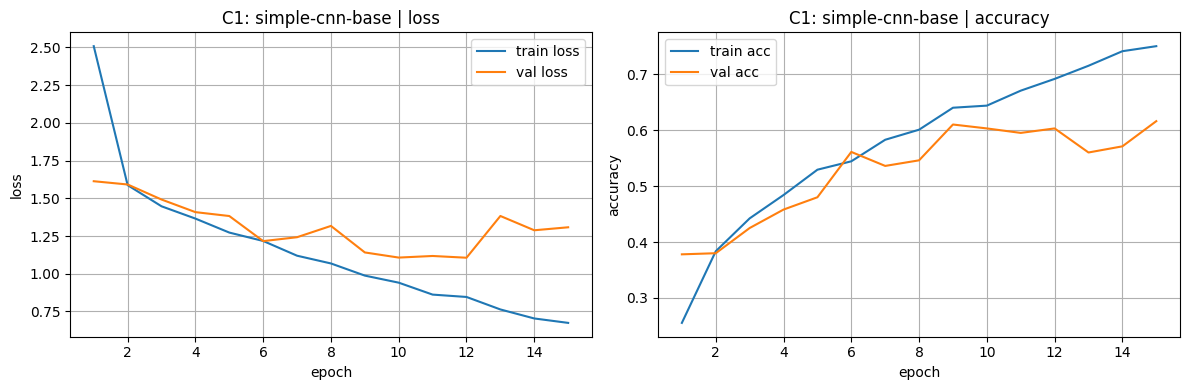

In [16]:
set_seed(RANDOM_STATE)
criterion = nn.CrossEntropyLoss()

model_c1 = SimpleCNN(NUM_CLASSES).to(DEVICE)
optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=1e-3, weight_decay=1e-4)

print("=" * 60)
print("C1: simple-cnn-base | STL10 | без аугментаций")
print("Trainable params:", count_params(model_c1))

hist_c1 = fit(
    model_c1, train_loader_base, val_loader_base,
    optimizer_c1, criterion, epochs=EPOCHS, verbose=True,
)

best_val_c1 = float(np.nanmax(hist_c1["val_acc"]))
print(f"\nC1 best_val_acc: {best_val_c1:.4f}")
plot_history(hist_c1, title="C1: simple-cnn-base")

### C2: SimpleCNN с аугментациями (simple-cnn-aug)

C2: simple-cnn-aug | STL10 | с аугментациями
Trainable params: 5113610
Epoch 01/15 | lr 1.00e-03 | train loss 2.6279, acc 0.205 | val loss 1.8315, acc 0.304 | 6.3s
Epoch 02/15 | lr 1.00e-03 | train loss 1.7898, acc 0.307 | val loss 1.6247, acc 0.360 | 5.4s
Epoch 03/15 | lr 1.00e-03 | train loss 1.6665, acc 0.351 | val loss 1.7285, acc 0.334 | 6.4s
Epoch 04/15 | lr 1.00e-03 | train loss 1.6229, acc 0.369 | val loss 1.5582, acc 0.390 | 5.5s
Epoch 05/15 | lr 1.00e-03 | train loss 1.5954, acc 0.383 | val loss 1.5686, acc 0.415 | 6.5s
Epoch 06/15 | lr 1.00e-03 | train loss 1.5053, acc 0.421 | val loss 1.4142, acc 0.453 | 5.4s
Epoch 07/15 | lr 1.00e-03 | train loss 1.4848, acc 0.428 | val loss 1.3513, acc 0.465 | 6.2s
Epoch 08/15 | lr 1.00e-03 | train loss 1.4554, acc 0.444 | val loss 1.3711, acc 0.479 | 5.4s
Epoch 09/15 | lr 1.00e-03 | train loss 1.4103, acc 0.462 | val loss 1.2563, acc 0.542 | 5.7s
Epoch 10/15 | lr 1.00e-03 | train loss 1.3795, acc 0.474 | val loss 1.2249, acc 0.540 | 6.0s

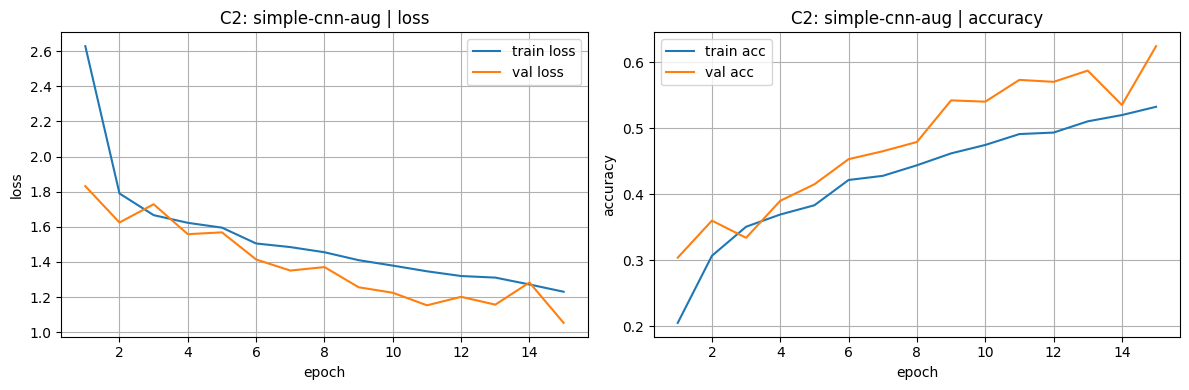

In [17]:
set_seed(RANDOM_STATE)

model_c2 = SimpleCNN(NUM_CLASSES).to(DEVICE)
optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=1e-3, weight_decay=1e-4)

print("=" * 60)
print("C2: simple-cnn-aug | STL10 | с аугментациями")
print("Trainable params:", count_params(model_c2))

hist_c2 = fit(
    model_c2, train_loader_aug, val_loader_base,
    optimizer_c2, criterion, epochs=EPOCHS, verbose=True,
)

best_val_c2 = float(np.nanmax(hist_c2["val_acc"]))
print(f"\nC2 best_val_acc: {best_val_c2:.4f}")
plot_history(hist_c2, title="C2: simple-cnn-aug")

### C3: ResNet18, только голова (resnet18-head-only)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]

C3: resnet18-head-only | STL10 | frozen backbone
Trainable params: 5130


Epoch 01/8 | lr 1.00e-03 | train loss 1.0516, acc 0.743 | val loss 0.4619, acc 0.892 | 16.6s
Epoch 02/8 | lr 1.00e-03 | train loss 0.3871, acc 0.914 | val loss 0.3080, acc 0.909 | 16.2s
Epoch 03/8 | lr 1.00e-03 | train loss 0.2904, acc 0.925 | val loss 0.2550, acc 0.923 | 16.4s
Epoch 04/8 | lr 1.00e-03 | train loss 0.2466, acc 0.935 | val loss 0.2298, acc 0.925 | 15.8s
Epoch 05/8 | lr 1.00e-03 | train loss 0.2187, acc 0.940 | val loss 0.2127, acc 0.932 | 16.6s
Epoch 06/8 | lr 1.00e-03 | train loss 0.2071, acc 0.939 | val loss 0.2100, acc 0.933 | 17.0s
Epoch 07/8 | lr 1.00e-03 | train loss 0.1892, acc 0.947 | val loss 0.1938, acc 0.937 | 16.0s
Epoch 08/8 | lr 1.00e-03 | train loss 0.1825, acc 0.943 | val loss 0.1904, acc 0.941 | 16.0s

C3 best_val_acc: 0.9410


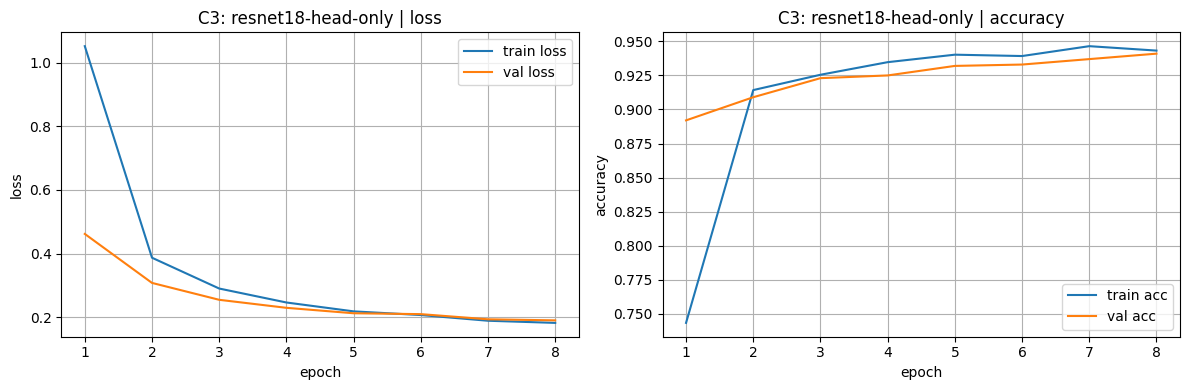

In [18]:
set_seed(RANDOM_STATE)

model_c3 = build_resnet18(NUM_CLASSES).to(DEVICE)

# Замораживаем весь backbone, обучаем только fc
set_requires_grad(model_c3, False)
set_requires_grad(model_c3.fc, True)

optimizer_c3 = torch.optim.Adam(model_c3.fc.parameters(), lr=1e-3)

print("=" * 60)
print("C3: resnet18-head-only | STL10 | frozen backbone")
print("Trainable params:", count_params(model_c3))

EPOCHS_HEAD = 3 if FAST_MODE else 8

hist_c3 = fit(
    model_c3, train_loader_rn, val_loader_rn,
    optimizer_c3, criterion, epochs=EPOCHS_HEAD, verbose=True,
)

best_val_c3 = float(np.nanmax(hist_c3["val_acc"]))
print(f"\nC3 best_val_acc: {best_val_c3:.4f}")
plot_history(hist_c3, title="C3: resnet18-head-only")

### C4: ResNet18, partial fine-tune (resnet18-finetune)

C4: resnet18-finetune | Phase 1: head-only
Trainable params: 5130
Epoch 01/5 | lr 1.00e-03 | train loss 1.0516, acc 0.743 | val loss 0.4619, acc 0.892 | 15.9s
Epoch 02/5 | lr 1.00e-03 | train loss 0.3871, acc 0.914 | val loss 0.3080, acc 0.909 | 16.4s
Epoch 03/5 | lr 1.00e-03 | train loss 0.2904, acc 0.925 | val loss 0.2550, acc 0.923 | 16.2s
Epoch 04/5 | lr 1.00e-03 | train loss 0.2466, acc 0.935 | val loss 0.2298, acc 0.925 | 16.1s
Epoch 05/5 | lr 1.00e-03 | train loss 0.2187, acc 0.940 | val loss 0.2127, acc 0.932 | 15.9s

C4: Phase 2: fine-tune layer4+fc
Trainable params: 8398858
Epoch 01/8 | lr 1.00e-04 | train loss 0.1967, acc 0.934 | val loss 0.1756, acc 0.946 | 16.1s
Epoch 02/8 | lr 1.00e-04 | train loss 0.0777, acc 0.976 | val loss 0.1289, acc 0.954 | 17.6s
Epoch 03/8 | lr 1.00e-04 | train loss 0.0559, acc 0.982 | val loss 0.1601, acc 0.950 | 16.3s
Epoch 04/8 | lr 1.00e-04 | train loss 0.0403, acc 0.989 | val loss 0.1509, acc 0.950 | 16.1s
Epoch 05/8 | lr 1.00e-04 | train loss

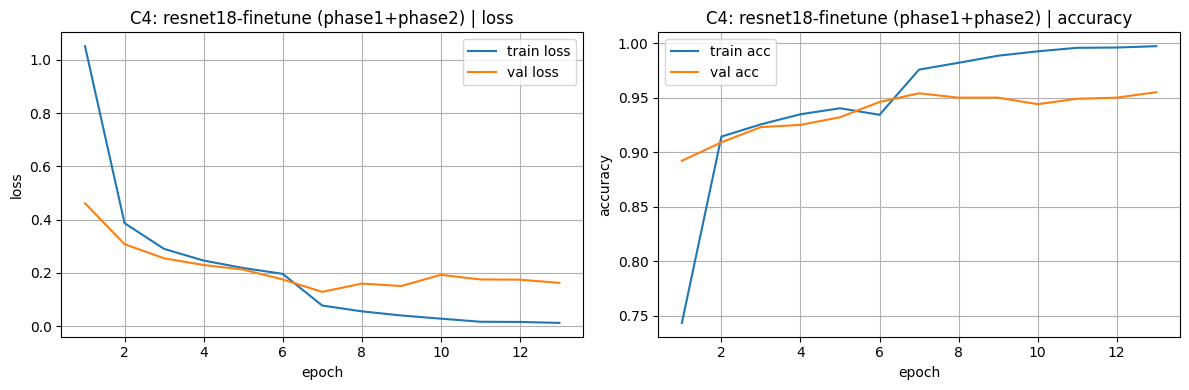

In [19]:
set_seed(RANDOM_STATE)

# Строим новую модель и начинаем с нуля (не продолжаем C3)
model_c4 = build_resnet18(NUM_CLASSES).to(DEVICE)

# Фаза 1: head-only (несколько эпох)
set_requires_grad(model_c4, False)
set_requires_grad(model_c4.fc, True)

opt_c4_head = torch.optim.Adam(model_c4.fc.parameters(), lr=1e-3)

EPOCHS_C4_HEAD = 2 if FAST_MODE else 5
EPOCHS_C4_FT   = 3 if FAST_MODE else 8

print("=" * 60)
print("C4: resnet18-finetune | Phase 1: head-only")
print("Trainable params:", count_params(model_c4))

hist_c4_phase1 = fit(
    model_c4, train_loader_rn, val_loader_rn,
    opt_c4_head, criterion, epochs=EPOCHS_C4_HEAD, verbose=True,
)

# Фаза 2: размораживаем layer4 + fc
set_requires_grad(model_c4.layer4, True)
set_requires_grad(model_c4.fc, True)

params_c4 = [
    {"params": model_c4.layer4.parameters(), "lr": 1e-4},
    {"params": model_c4.fc.parameters(),     "lr": 1e-3},
]
opt_c4_ft = torch.optim.Adam(params_c4, weight_decay=1e-4)

print("\nC4: Phase 2: fine-tune layer4+fc")
print("Trainable params:", count_params(model_c4))

hist_c4_phase2 = fit(
    model_c4, train_loader_rn, val_loader_rn,
    opt_c4_ft, criterion, epochs=EPOCHS_C4_FT, verbose=True,
)

# Объединяем историю
hist_c4 = {
    k: hist_c4_phase1[k] + hist_c4_phase2[k]
    for k in hist_c4_phase1
}

best_val_c4 = float(np.nanmax(hist_c4["val_acc"]))
print(f"\nC4 best_val_acc: {best_val_c4:.4f}")
plot_history(hist_c4, title="C4: resnet18-finetune (phase1+phase2)")

## 5. Выбор лучшей модели и финальный test

In [20]:
# Сравниваем C1–C4 по best_val_acc
results_cls = {
    "C1": {"model": model_c1, "hist": hist_c1, "best_val_acc": best_val_c1, "loader": test_loader_base},
    "C2": {"model": model_c2, "hist": hist_c2, "best_val_acc": best_val_c2, "loader": test_loader_aug},
    "C3": {"model": model_c3, "hist": hist_c3, "best_val_acc": best_val_c3, "loader": test_loader_rn},
    "C4": {"model": model_c4, "hist": hist_c4, "best_val_acc": best_val_c4, "loader": test_loader_rn},
}

print("Сравнение экспериментов C1–C4 по best_val_accuracy:")
for exp_id, r in results_cls.items():
    print(f"  {exp_id}: {r['best_val_acc']:.4f}")

best_exp_id = max(results_cls, key=lambda k: results_cls[k]["best_val_acc"])
print(f"\nЛучший эксперимент: {best_exp_id} (val_acc={results_cls[best_exp_id]['best_val_acc']:.4f})")

# Финальная оценка на test — только один раз, для лучшей модели
best_model  = results_cls[best_exp_id]["model"]
best_loader = results_cls[best_exp_id]["loader"]
test_acc_best = accuracy_on_loader(best_model, best_loader)
print(f"Test accuracy лучшей модели ({best_exp_id}): {test_acc_best:.4f}")

Сравнение экспериментов C1–C4 по best_val_accuracy:
  C1: 0.6160
  C2: 0.6240
  C3: 0.9410
  C4: 0.9550

Лучший эксперимент: C4 (val_acc=0.9550)
Test accuracy лучшей модели (C4): 0.9519


## 6. Артефакты части A

In [21]:
# Сохраняем лучшую модель
best_model_path = os.path.join(ARTIFACTS_DIR, "best_classifier.pt")
torch.save(best_model.state_dict(), best_model_path)
print("Модель сохранена:", best_model_path)

Модель сохранена: ./artifacts/best_classifier.pt


In [22]:
# Сохраняем конфиг лучшей модели
best_config = {
    "experiment_id": best_exp_id,
    "dataset": "STL10",
    "num_classes": NUM_CLASSES,
    "architecture": "ResNet18" if "resnet" in best_exp_id.lower() else "SimpleCNN",
    "seed": RANDOM_STATE,
    "batch_size": BATCH_SIZE,
    "loss": "CrossEntropyLoss",
    "optimizer": "Adam",
    "best_val_accuracy": round(results_cls[best_exp_id]["best_val_acc"], 4),
    "test_accuracy": round(test_acc_best, 4),
    "img_size": IMG_SIZE_RN if "resnet" in best_exp_id.lower() else IMG_SIZE_CNN,
    "normalize_mean": IMAGENET_MEAN if "resnet" in best_exp_id.lower() else STL10_MEAN,
    "normalize_std":  IMAGENET_STD  if "resnet" in best_exp_id.lower() else STL10_STD,
    "augmentations": (
        "RandomResizedCrop, RandomHorizontalFlip" if "resnet" in best_exp_id.lower()
        else ("RandomHorizontalFlip, RandomCrop, ColorJitter" if best_exp_id == "C2" else "None")
    ),
}

config_path = os.path.join(ARTIFACTS_DIR, "best_classifier_config.json")
with open(config_path, "w") as f:
    json.dump(best_config, f, indent=2)
print("Конфиг сохранён:", config_path)
print(json.dumps(best_config, indent=2))

Конфиг сохранён: ./artifacts/best_classifier_config.json
{
  "experiment_id": "C4",
  "dataset": "STL10",
  "num_classes": 10,
  "architecture": "SimpleCNN",
  "seed": 42,
  "batch_size": 64,
  "loss": "CrossEntropyLoss",
  "optimizer": "Adam",
  "best_val_accuracy": 0.955,
  "test_accuracy": 0.9519,
  "img_size": 96,
  "normalize_mean": [
    0.4467,
    0.4398,
    0.4066
  ],
  "normalize_std": [
    0.2603,
    0.2566,
    0.2713
  ],
  "augmentations": "None"
}


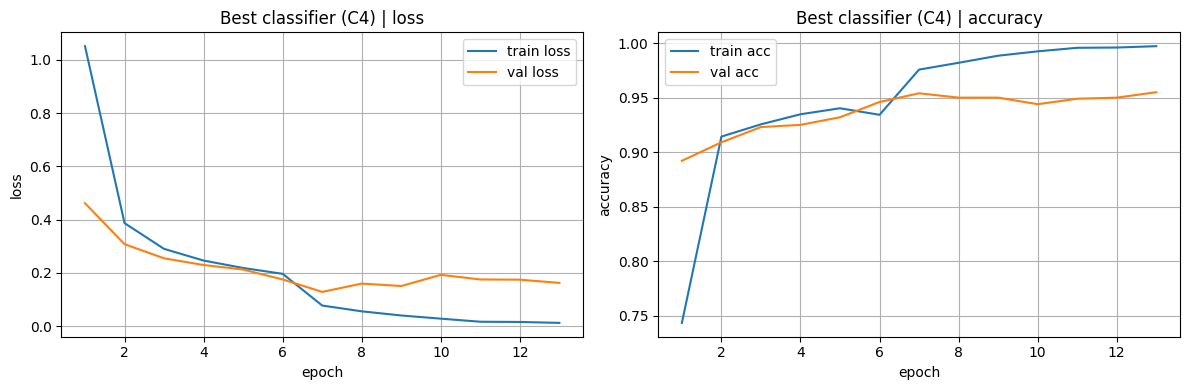

Сохранено: classification_curves_best.png


In [23]:
# График лучшего прогона
plot_history(
    results_cls[best_exp_id]["hist"],
    title=f"Best classifier ({best_exp_id})",
    save_path=os.path.join(FIGURES_DIR, "classification_curves_best.png"),
)
print("Сохранено: classification_curves_best.png")

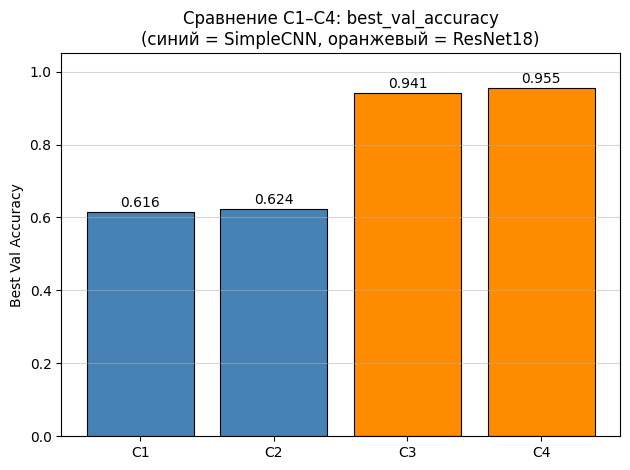

Сохранено: classification_compare.png


In [24]:
# Сравнительный bar-plot C1–C4
exp_ids = list(results_cls.keys())
val_accs = [results_cls[e]["best_val_acc"] for e in exp_ids]

colors = ["steelblue", "steelblue", "darkorange", "darkorange"]
bars = plt.bar(exp_ids, val_accs, color=colors, edgecolor="black", linewidth=0.8)

for bar, acc in zip(bars, val_accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{acc:.3f}", ha="center", va="bottom", fontsize=10)

plt.ylim(0, 1.05)
plt.ylabel("Best Val Accuracy")
plt.title("Сравнение C1–C4: best_val_accuracy\n(синий = SimpleCNN, оранжевый = ResNet18)")
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "classification_compare.png"), dpi=100, bbox_inches="tight")
plt.show()
print("Сохранено: classification_compare.png")

## 7. Часть B: Detection (Pascal VOC + FasterRCNN)

Используем COCO-pretrained `FasterRCNN_ResNet50_FPN_V2` из torchvision.  
COCO label 15 = «person». Проводим два режима инференса:
- **V1**: `score_threshold = 0.3`
- **V2**: `score_threshold = 0.7`

Для каждого режима считаем precision, recall, mean_iou по IoU@0.5 на подвыборке VOC val.

In [25]:
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)

det_weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
det_model = fasterrcnn_resnet50_fpn_v2(weights=det_weights)
det_model.to(DEVICE)
det_model.eval()

COCO_CATEGORIES = det_weights.meta.get("categories", [])
print("COCO categories (первые 10):", COCO_CATEGORIES[:10])

# Маппинг: VOC class -> COCO label index
# COCO использует 1-based индексацию для категорий (0 = background)
# Для соответствия VOC и COCO построим словарь по общим именам
COCO_NAME_TO_IDX = {name: i for i, name in enumerate(COCO_CATEGORIES)}
print("\nCOCO person index:", COCO_NAME_TO_IDX.get("person"))

# Функция: для изображения из VOC найдём соответствующие COCO labels
def voc_label_to_coco(voc_class_name: str) -> Optional[int]:
    """Возвращает индекс в COCO categories для VOC класса."""
    # Большинство имён совпадают (person, car, bus, etc.)
    mapping = {
        "aeroplane": "airplane",
        "motorbike": "motorcycle",
        "pottedplant": "potted plant",
        "tvmonitor": "tv",
        "diningtable": "dining table",
        "sofa": "couch",
    }
    name = mapping.get(voc_class_name, voc_class_name)
    return COCO_NAME_TO_IDX.get(name)

print("\nПроверка маппинга:")
for cls in ["person", "car", "cat", "aeroplane", "tvmonitor", "sofa"]:
    print(f"  {cls} -> COCO idx: {voc_label_to_coco(cls)}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 126MB/s]


COCO categories (первые 10): ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']

COCO person index: 1

Проверка маппинга:
  person -> COCO idx: 1
  car -> COCO idx: 3
  cat -> COCO idx: 17
  aeroplane -> COCO idx: 5
  tvmonitor -> COCO idx: 72
  sofa -> COCO idx: 63


In [26]:
# Функции для detection
from torchvision.transforms.functional import to_tensor

@torch.no_grad()
def predict_detection(img_pil: Image.Image) -> Dict[str, torch.Tensor]:
    """Запускаем детектор на PIL-изображении, возвращаем словарь предсказаний."""
    img_t = to_tensor(img_pil).to(DEVICE)
    out = det_model([img_t])[0]
    return {k: v.detach().cpu() for k, v in out.items()}


def filter_detection(pred: Dict, score_thr: float) -> Dict:
    """Фильтруем предсказания по порогу score."""
    keep = pred["scores"] >= score_thr
    return {k: v[keep] for k, v in pred.items()}


def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    """[N,4] x [M,4] -> [N,M] IoU matrix."""
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union


def match_greedy(
    pred_boxes: torch.Tensor,
    pred_scores: torch.Tensor,
    gt_boxes: torch.Tensor,
    iou_thr: float = 0.5,
) -> Tuple[int, int, int, float]:
    """Жадный матчинг pred -> GT. Возвращает TP, FP, FN, mean_iou."""
    if pred_boxes.numel() == 0:
        return 0, 0, int(gt_boxes.shape[0]), float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P,G]
    gt_used = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool)

    tp, fp = 0, 0
    ious_matched = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        best_iou, best_j = torch.max(iou[p], dim=0)
        best_iou, best_j = float(best_iou.item()), int(best_j.item())

        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious_matched.append(best_iou)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(ious_matched)) if ious_matched else float("nan")
    return tp, fp, fn, mean_iou


def draw_boxes(ax, boxes, color="r", linewidth=2, labels=None):
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=linewidth, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        if labels is not None:
            ax.text(x1, max(y1 - 2, 0), labels[i], color=color, fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1))


print("Функции детекции определены.")

Функции детекции определены.


In [27]:
# Выбираем подвыборку VOC для evaluation
N_EVAL_DET = 30 if FAST_MODE else 100
eval_indices_det = list(range(min(N_EVAL_DET, len(voc_dataset))))

print(f"Evaluation subset size: {len(eval_indices_det)} изображений")


def evaluate_detection(score_thr: float, iou_thr: float = 0.5) -> Dict[str, float]:
    """Считаем TP/FP/FN/precision/recall/mean_iou для всего evaluation subset."""
    total_tp = total_fp = total_fn = 0
    all_ious = []

    for idx in eval_indices_det:
        img_pil, annotation = voc_dataset[idx]
        gt_boxes, gt_labels = parse_voc_target(annotation)

        if gt_boxes.shape[0] == 0:
            continue

        pred = predict_detection(img_pil)
        pred_f = filter_detection(pred, score_thr)

        # Переводим GT в COCO label ids
        # Фильтруем предсказания: оставляем только классы, присутствующие в GT
        gt_coco_labels = set()
        for lbl in gt_labels:
            coco_idx = voc_label_to_coco(VOC_CLASSES[lbl.item()])
            if coco_idx is not None:
                gt_coco_labels.add(coco_idx)

        if len(gt_coco_labels) == 0:
            continue

        # Оставляем только предсказания нужных классов
        if pred_f["boxes"].shape[0] > 0:
            mask = torch.zeros(pred_f["labels"].shape[0], dtype=torch.bool)
            for coco_lbl in gt_coco_labels:
                mask |= (pred_f["labels"] == coco_lbl)
            filtered_boxes = pred_f["boxes"][mask]
            filtered_scores = pred_f["scores"][mask]
        else:
            filtered_boxes = pred_f["boxes"]
            filtered_scores = pred_f["scores"]

        tp, fp, fn, miou = match_greedy(filtered_boxes, filtered_scores, gt_boxes, iou_thr)
        total_tp += tp
        total_fp += fp
        total_fn += fn
        if math.isfinite(miou):
            all_ious.append(miou)

    precision = total_tp / (total_tp + total_fp + 1e-9)
    recall    = total_tp / (total_tp + total_fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou  = float(np.mean(all_ious)) if all_ious else float("nan")

    return {
        "score_threshold": score_thr,
        "TP": total_tp, "FP": total_fp, "FN": total_fn,
        "precision": round(precision, 4),
        "recall":    round(recall, 4),
        "F1":        round(f1, 4),
        "mean_iou":  round(mean_iou, 4) if math.isfinite(mean_iou) else float("nan"),
    }


print("Функция evaluate_detection определена.")

Evaluation subset size: 100 изображений
Функция evaluate_detection определена.


In [28]:
# V1: score_threshold = 0.3
print("Запускаем V1 (score_threshold=0.3)...")
metrics_v1 = evaluate_detection(score_thr=0.3)
print("V1 результаты:", metrics_v1)

Запускаем V1 (score_threshold=0.3)...
V1 результаты: {'score_threshold': 0.3, 'TP': 282, 'FP': 238, 'FN': 19, 'precision': 0.5423, 'recall': 0.9369, 'F1': 0.687, 'mean_iou': 0.8645}


In [29]:
# V2: score_threshold = 0.7
print("Запускаем V2 (score_threshold=0.7)...")
metrics_v2 = evaluate_detection(score_thr=0.7)
print("V2 результаты:", metrics_v2)

Запускаем V2 (score_threshold=0.7)...
V2 результаты: {'score_threshold': 0.7, 'TP': 270, 'FP': 87, 'FN': 31, 'precision': 0.7563, 'recall': 0.897, 'F1': 0.8207, 'mean_iou': 0.8691}


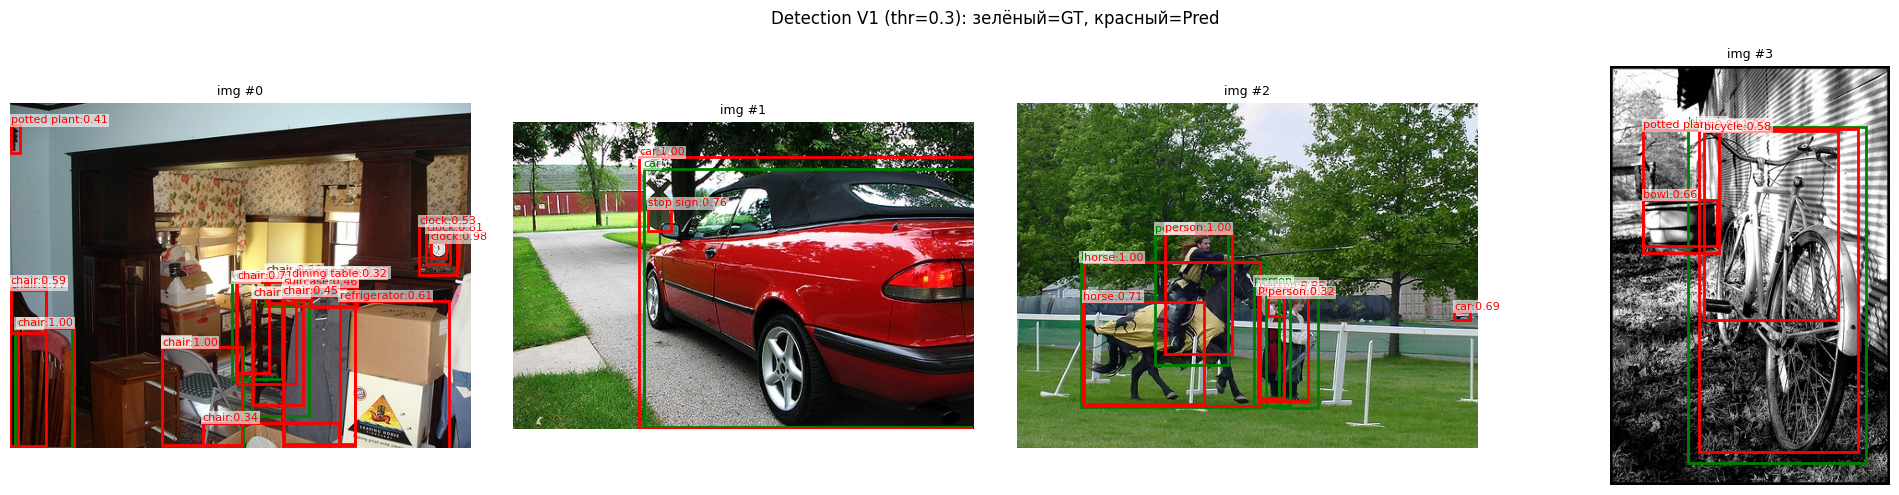

Сохранено: detection_examples_v1.png


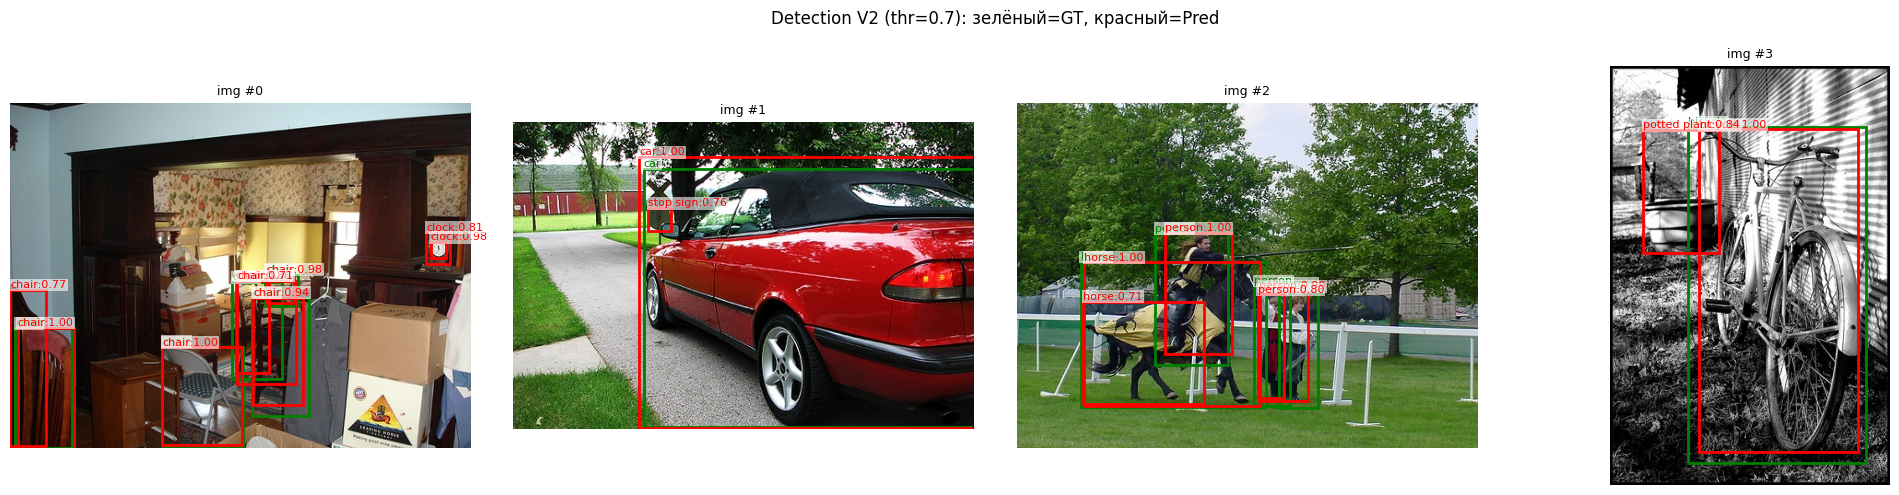

Сохранено: detection_examples_v2.png


In [30]:
# Визуализация предсказаний на примерах
N_VIS = 4
vis_indices = list(range(min(N_VIS, len(voc_dataset))))

for score_thr, mode_name in [(0.3, "V1 (thr=0.3)"), (0.7, "V2 (thr=0.7)")]:
    fig, axes = plt.subplots(1, N_VIS, figsize=(5 * N_VIS, 5))
    fig.suptitle(f"Detection {mode_name}: зелёный=GT, красный=Pred", fontsize=12)

    for i, idx in enumerate(vis_indices):
        img_pil, annotation = voc_dataset[idx]
        gt_boxes, gt_labels = parse_voc_target(annotation)
        pred = predict_detection(img_pil)
        pred_f = filter_detection(pred, score_thr)

        ax = axes[i]
        ax.imshow(img_pil)
        ax.set_title(f"img #{idx}", fontsize=9)
        ax.axis("off")

        # GT boxes (зелёный)
        gt_label_names = [VOC_CLASSES[l.item()] for l in gt_labels]
        draw_boxes(ax, gt_boxes, color="green", linewidth=2, labels=gt_label_names)

        # Predicted boxes (красный)
        if pred_f["boxes"].shape[0] > 0:
            pred_label_names = [
                f"{COCO_CATEGORIES[pred_f['labels'][j].item()]}:{pred_f['scores'][j]:.2f}"
                if pred_f['labels'][j].item() < len(COCO_CATEGORIES) else str(pred_f['labels'][j].item())
                for j in range(pred_f["boxes"].shape[0])
            ]
            draw_boxes(ax, pred_f["boxes"], color="red", linewidth=2, labels=pred_label_names)

    plt.tight_layout()
    fname = f"detection_examples_{'v1' if '0.3' in mode_name else 'v2'}.png"
    plt.savefig(os.path.join(FIGURES_DIR, fname), dpi=100, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {fname}")

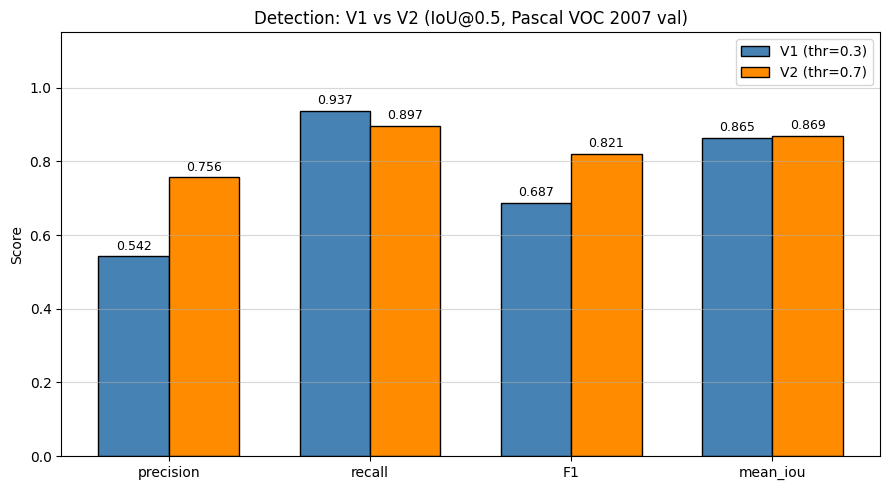

Сохранено: detection_metrics.png


In [31]:
# Bar-plot сравнения V1 vs V2
metrics_keys = ["precision", "recall", "F1", "mean_iou"]
v1_vals = [metrics_v1.get(k, 0) or 0 for k in metrics_keys]
v2_vals = [metrics_v2.get(k, 0) or 0 for k in metrics_keys]

x = np.arange(len(metrics_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, v1_vals, width, label="V1 (thr=0.3)", color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width/2, v2_vals, width, label="V2 (thr=0.7)", color="darkorange", edgecolor="black")

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_keys)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Detection: V1 vs V2 (IoU@0.5, Pascal VOC 2007 val)")
ax.legend()
ax.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "detection_metrics.png"), dpi=100, bbox_inches="tight")
plt.show()
print("Сохранено: detection_metrics.png")

## 8. Сохранение runs.csv

In [32]:
# Описание конфигураций
model_summaries = {
    "C1": "SimpleCNN(4xConv+BN+Pool, fc512, Dropout0.4) | no aug",
    "C2": "SimpleCNN(4xConv+BN+Pool, fc512, Dropout0.4) | HFlip+Crop+ColorJitter",
    "C3": "ResNet18(pretrained) | frozen backbone, head-only",
    "C4": "ResNet18(pretrained) | head-only->finetune layer4+fc",
    "V1": "FasterRCNN_ResNet50_FPN_V2(COCO-pretrained) | score_thr=0.3",
    "V2": "FasterRCNN_ResNet50_FPN_V2(COCO-pretrained) | score_thr=0.7",
}

optimizer_names = {"C1": "Adam", "C2": "Adam", "C3": "Adam", "C4": "Adam", "V1": "N/A", "V2": "N/A"}
lr_values = {"C1": "1e-3", "C2": "1e-3", "C3": "1e-3", "C4": "1e-3/1e-4", "V1": "N/A", "V2": "N/A"}

epochs_trained = {
    "C1": len(hist_c1["train_loss"]),
    "C2": len(hist_c2["train_loss"]),
    "C3": len(hist_c3["train_loss"]),
    "C4": len(hist_c4["train_loss"]),
    "V1": "N/A",
    "V2": "N/A",
}

rows = []

# C1–C4
for exp_id in ["C1", "C2", "C3", "C4"]:
    val_acc = results_cls[exp_id]["best_val_acc"]
    t_acc = test_acc_best if exp_id == best_exp_id else ""
    rows.append({
        "experiment_id":  exp_id,
        "task":           "classification",
        "dataset":        "STL10",
        "seed":           RANDOM_STATE,
        "model_summary":  model_summaries[exp_id],
        "optimizer":      optimizer_names[exp_id],
        "lr":             lr_values[exp_id],
        "epochs_trained": epochs_trained[exp_id],
        "best_val_accuracy": round(val_acc, 4),
        "test_accuracy":  round(test_acc_best, 4) if exp_id == best_exp_id else "",
        "precision":      "",
        "recall":         "",
        "mean_iou":       "",
        "notes":          "best" if exp_id == best_exp_id else "",
    })

# V1, V2
for mode, metrics in [("V1", metrics_v1), ("V2", metrics_v2)]:
    rows.append({
        "experiment_id":  mode,
        "task":           "detection",
        "dataset":        "Pascal VOC 2007 val",
        "seed":           RANDOM_STATE,
        "model_summary":  model_summaries[mode],
        "optimizer":      "N/A",
        "lr":             "N/A",
        "epochs_trained": "N/A",
        "best_val_accuracy": "",
        "test_accuracy":  "",
        "precision":      metrics["precision"],
        "recall":         metrics["recall"],
        "mean_iou":       metrics["mean_iou"],
        "notes":          f"IoU@0.5, score_thr={metrics['score_threshold']}",
    })

# Сохраняем CSV
csv_path = os.path.join(ARTIFACTS_DIR, "runs.csv")
fieldnames = [
    "experiment_id", "task", "dataset", "seed", "model_summary",
    "optimizer", "lr", "epochs_trained", "best_val_accuracy", "test_accuracy",
    "precision", "recall", "mean_iou", "notes"
]

with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("runs.csv сохранён:", csv_path)

# Показываем таблицу
print("\n" + "=" * 80)
print(f"{'exp_id':6} {'task':14} {'best_val_acc':14} {'test_acc':10} {'precision':10} {'recall':10} {'mean_iou':10}")
print("-" * 80)
for r in rows:
    print(
        f"{r['experiment_id']:6} {r['task']:14} "
        f"{str(r['best_val_accuracy']):14} {str(r['test_accuracy']):10} "
        f"{str(r['precision']):10} {str(r['recall']):10} {str(r['mean_iou']):10}"
    )

runs.csv сохранён: ./artifacts/runs.csv

exp_id task           best_val_acc   test_acc   precision  recall     mean_iou  
--------------------------------------------------------------------------------
C1     classification 0.616                                                     
C2     classification 0.624                                                     
C3     classification 0.941                                                     
C4     classification 0.955          0.9519                                     
V1     detection                                0.5423     0.9369     0.8645    
V2     detection                                0.7563     0.897      0.8691    


In [33]:
# Финальная сводка
print("=" * 60)
print("ИТОГИ ДОМАШНЕЙ РАБОТЫ HW10-11")
print("=" * 60)
print(f"Датасет части A:  STL10 (10 классов, 96x96 RGB)")
print(f"Датасет части B:  Pascal VOC 2007 val (detection)")
print()
print("Часть A — классификация:")
for exp_id in ["C1", "C2", "C3", "C4"]:
    marker = " <-- BEST" if exp_id == best_exp_id else ""
    print(f"  {exp_id}: best_val_acc = {results_cls[exp_id]['best_val_acc']:.4f}{marker}")
print(f"  Test accuracy ({best_exp_id}): {test_acc_best:.4f}")
print()
print("Часть B — detection (IoU@0.5):")
print(f"  V1 (thr=0.3): precision={metrics_v1['precision']:.4f}, recall={metrics_v1['recall']:.4f}, mean_iou={metrics_v1['mean_iou']:.4f}")
print(f"  V2 (thr=0.7): precision={metrics_v2['precision']:.4f}, recall={metrics_v2['recall']:.4f}, mean_iou={metrics_v2['mean_iou']:.4f}")
print()
print("Артефакты:")
for f in os.listdir(ARTIFACTS_DIR):
    print(f"  artifacts/{f}")
for f in os.listdir(FIGURES_DIR):
    print(f"  artifacts/figures/{f}")

ИТОГИ ДОМАШНЕЙ РАБОТЫ HW10-11
Датасет части A:  STL10 (10 классов, 96x96 RGB)
Датасет части B:  Pascal VOC 2007 val (detection)

Часть A — классификация:
  C1: best_val_acc = 0.6160
  C2: best_val_acc = 0.6240
  C3: best_val_acc = 0.9410
  C4: best_val_acc = 0.9550 <-- BEST
  Test accuracy (C4): 0.9519

Часть B — detection (IoU@0.5):
  V1 (thr=0.3): precision=0.5423, recall=0.9369, mean_iou=0.8645
  V2 (thr=0.7): precision=0.7563, recall=0.8970, mean_iou=0.8691

Артефакты:
  artifacts/best_classifier.pt
  artifacts/best_classifier_config.json
  artifacts/runs.csv
  artifacts/figures
  artifacts/figures/classification_curves_best.png
  artifacts/figures/detection_examples_v1.png
  artifacts/figures/detection_examples_v2.png
  artifacts/figures/augmentations_preview.png
  artifacts/figures/classification_compare.png
  artifacts/figures/detection_metrics.png
